# POC Model
- Initial stock ranking model within-portfolio

## Things to Test
- Which response variable and model structure?
    - Structure
        - Simple saturated model with 1 Train and Test (Up to 2024, 2024 to present)
    - Types
        - Quantile rank model
        - Lambda rank model
        - Regression Model (_tweedie or weighted MSE_)
- CV Structure
    - Test purged and embargoed 3/4/5-Fold Cross Validation
    - Compare errors and generalization vs. simple Train/Test

- Variable Selection
    - Based on SHAP and temporal signal consistency

In [ ]:
# %pip install matplotlib
# %pip install xgboost==3.0.2

import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt

from importlib import reload 
import src.data_fetch.fetch_fundamentals_quarterly 


<module 'src.data_fetch.fetch_fundamentals_quarterly' from 'c:\\Users\\amsac\\Desktop\\repos\\multimodal-stock-ranking\\notebooks\\..\\src\\data_fetch\\fetch_fundamentals_quarterly.py'>

### Helper Functions

In [ ]:
def error_plots(
    df,
    features,
    target_col,
    pred_col=None,
    weight_col=None,
    n_bins=10
):
    """
    Creates weighted error plots for one or more features.

    Parameters
    ----------
    df : DataFrame
    features : list of column names
    target_col : actual target column
    pred_col : optional prediction column
    weight_col : optional weight column
    n_bins : number of bins for continuous variables
    """

    for feature in features:

        data = df[[feature, target_col]].copy()

        if pred_col:
            data[pred_col] = df[pred_col]

        if weight_col:
            data["weight"] = df[weight_col]
        else:
            data["weight"] = 1.0

        # Drop NA
        data = data.dropna()

        # --- Bin continuous variables ---
        if pd.api.types.is_numeric_dtype(data[feature]):
            data["bin"] = pd.qcut(
                data[feature],
                q=n_bins,
                duplicates="drop"
            )
        else:
            data["bin"] = data[feature]

        # --- Weighted aggregation ---
        def weighted_avg(x, val_col):
            return np.average(x[val_col], weights=x["weight"])

        grouped = data.groupby("bin")

        actual = grouped.apply(lambda x: weighted_avg(x, target_col))
        count = grouped["weight"].sum()

        if pred_col:
            pred = grouped.apply(lambda x: weighted_avg(x, pred_col))

        # --- Plot ---
        plt.figure(figsize=(8, 5))

        x_vals = range(len(actual))

        plt.plot(x_vals, actual.values)

        if pred_col:
            plt.plot(x_vals, pred.values)

        plt.xticks(x_vals, actual.index.astype(str), rotation=45)
        plt.title(f"Error Plot: {feature}")
        plt.ylabel("Weighted Mean")
        plt.tight_layout()
        plt.show()


def plot_feature_importance(model, features, top_n=20, title="Feature Importance"):
    """Plot horizontal bar chart of top feature importances."""
    importance_df = pd.DataFrame({
        "feature": features,
        "importance": model.feature_importances_
    }).sort_values("importance", ascending=False).head(top_n)

    importance_df = importance_df.sort_values("importance", ascending=True)

    plt.figure(figsize=(8, 6))
    plt.barh(importance_df["feature"], importance_df["importance"])
    plt.xlabel("Importance")
    plt.title(title)
    plt.tight_layout()
    plt.show()



In [128]:
def backtest_monthly_dollar(
    test_df,
    pred_col="pred",
    long_class=None,
    top_pct=None,
    short_class=None,
    short_pct=None,
    price_col="close",
    initial_capital=10000,
    transaction_cost_bps=10,
    monthly_contribution=0,
    short_term_tax_rate=0.35,
    borrow_cost_annual=0.03
):

    if long_class is None and top_pct is None:
        raise ValueError("Must specify either long_class or top_pct")

    df = test_df.copy()
    df = df.sort_values("date")
    df["year_month"] = df["date"].dt.to_period("M")

    capital = initial_capital
    portfolio_value_history = []
    turnover_history = []

    months = df["year_month"].unique()

    for i, month in enumerate(months):

        month_data = df[df["year_month"] == month]
        month_dates = month_data["date"].sort_values()
        first_date, last_date = month_dates.iloc[0], month_dates.iloc[-1]

        first_day = month_data[month_data["date"] == first_date]
        last_day = month_data[month_data["date"] == last_date]

        if i > 0:
            capital += monthly_contribution

        # =========================
        # LONG SELECTION
        # =========================
        if long_class is not None:
            long_selected = first_day[first_day[pred_col] == long_class]
        else:
            cutoff = first_day[pred_col].quantile(1 - top_pct)
            long_selected = first_day[first_day[pred_col] >= cutoff]

        long_tickers = long_selected["ticker"].unique()

        # =========================
        # SHORT SELECTION
        # =========================
        short_tickers = []

        if short_class is not None:
            short_selected = first_day[first_day[pred_col] == short_class]
            short_tickers = short_selected["ticker"].unique()

        elif short_pct is not None:
            cutoff = first_day[pred_col].quantile(short_pct)
            short_selected = first_day[first_day[pred_col] <= cutoff]
            short_tickers = short_selected["ticker"].unique()

        n_long = len(long_tickers)
        n_short = len(short_tickers)

        if n_long == 0 and n_short == 0:
            portfolio_value_history.append(capital)
            turnover_history.append(0)
            continue

        # =========================
        # DOLLAR NEUTRAL WEIGHTS
        # =========================
        if n_short > 0:
            long_weight = 0.5
            short_weight = 0.5
        else:
            long_weight = 1.0
            short_weight = 0.0

        shares_long = {}
        shares_short = {}

        # Long leg
        for ticker in long_tickers:
            price = first_day[first_day["ticker"] == ticker][price_col].values[0]
            alloc = capital * long_weight / n_long
            shares_long[ticker] = alloc / price

        # Short leg
        for ticker in short_tickers:
            price = first_day[first_day["ticker"] == ticker][price_col].values[0]
            alloc = capital * short_weight / n_short
            shares_short[ticker] = alloc / price

        # =========================
        # END VALUE CALCULATION
        # =========================
        end_value = capital

        # Long PnL
        for ticker, qty in shares_long.items():
            if ticker in last_day["ticker"].values:
                start_price = first_day[first_day["ticker"] == ticker][price_col].values[0]
                end_price = last_day[last_day["ticker"] == ticker][price_col].values[0]
                pnl = qty * (end_price - start_price)
                end_value += pnl

        # Short PnL + borrow cost
        for ticker, qty in shares_short.items():
            if ticker in last_day["ticker"].values:
                start_price = first_day[first_day["ticker"] == ticker][price_col].values[0]
                end_price = last_day[last_day["ticker"] == ticker][price_col].values[0]
                pnl = qty * (start_price - end_price)
                end_value += pnl

                borrow_fee = qty * start_price * (borrow_cost_annual / 12)
                end_value -= borrow_fee

        # =========================
        # TRANSACTION COSTS
        # =========================
        gross_exposure = capital * (long_weight + short_weight)
        turnover = gross_exposure
        cost = turnover * (transaction_cost_bps / 10000)
        end_value -= cost

        # =========================
        # TAXES (apply to net profit)
        # =========================
        gross_profit = end_value - capital
        tax = gross_profit * short_term_tax_rate if gross_profit > 0 else 0
        capital = end_value - tax

        portfolio_value_history.append(capital)
        turnover_history.append(turnover)

    # ==============================
    # RESULTS
    # ==============================
    results = pd.DataFrame({
        "month": months,
        "portfolio_value": portfolio_value_history,
        "turnover": turnover_history
    })

    results["monthly_return"] = results["portfolio_value"].pct_change().fillna(0)
    results["cumulative_return"] = results["portfolio_value"] / initial_capital - 1

    # ==============================
    # SPY BENCHMARK
    # ==============================
    spy = df.query("ticker == 'SPY'").copy()
    spy = spy.sort_values("date")
    spy["year_month"] = spy["date"].dt.to_period("M")

    spy_monthly = (
        spy.groupby("year_month")
        .agg(start_price=(price_col, "first"),
             end_price=(price_col, "last"))
        .reset_index()
    )

    spy_monthly["monthly_return"] = (
        spy_monthly["end_price"] / spy_monthly["start_price"] - 1
    )

    spy_monthly["portfolio_value"] = (
        initial_capital *
        (1 + spy_monthly["monthly_return"]).cumprod()
    )

    results = results.merge(
        spy_monthly[["year_month", "monthly_return", "portfolio_value"]],
        left_on="month",
        right_on="year_month",
        how="left",
        suffixes=("", "_spy")
    )

    results["cumulative_return_spy"] = (
        results["portfolio_value_spy"] / initial_capital - 1
    )

    # ==============================
    # METRICS
    # ==============================
    def compute_metrics(returns, values):
        ann_return = (1 + returns.mean())**12 - 1
        ann_vol = returns.std() * np.sqrt(12)
        sharpe = returns.mean() / returns.std() * np.sqrt(12)

        running_max = values.cummax()
        drawdown = values / running_max - 1
        max_dd = drawdown.min()

        total_return = values.iloc[-1] / values.iloc[0] - 1
        years = len(returns) / 12
        cagr = (1 + total_return)**(1/years) - 1

        return ann_return, ann_vol, sharpe, max_dd, cagr, drawdown

    strat_metrics = compute_metrics(
        results["monthly_return"],
        results["portfolio_value"]
    )

    spy_metrics = compute_metrics(
        results["monthly_return_spy"],
        results["portfolio_value_spy"]
    )

    # ==============================
    # ALPHA / BETA REGRESSION
    # ==============================
    import statsmodels.api as sm

    y = results["monthly_return"]
    X = sm.add_constant(results["monthly_return_spy"])
    model = sm.OLS(y, X).fit()

    alpha = model.params["const"]
    beta = model.params["monthly_return_spy"]
    alpha_p = model.pvalues["const"]
    beta_p = model.pvalues["monthly_return_spy"]

    print("\n=== Strategy vs SPY Alpha (Intercept) and Beta (Slope) ===")
    print(f"Alpha: {alpha:.6f}  |  p-value: {alpha_p:.6f}")
    print(f"Beta:  {beta:.6f}  |  p-value: {beta_p:.6f}")

    # ==============================
    # PRINT COMPARISON
    # ==============================
    print("\n=== Strategy vs SPY Comparison ===")
    print(f"{'Metric':<20}{'Strategy':>15}{'SPY':>15}")
    print("-"*50)
    print(f"{'Annual Return':<20}{strat_metrics[0]:>15.2%}{spy_metrics[0]:>15.2%}")
    print(f"{'Volatility':<20}{strat_metrics[1]:>15.2%}{spy_metrics[1]:>15.2%}")
    print(f"{'Sharpe':<20}{strat_metrics[2]:>15.2f}{spy_metrics[2]:>15.2f}")
    print(f"{'Max Drawdown':<20}{strat_metrics[3]:>15.2%}{spy_metrics[3]:>15.2%}")
    print(f"{'CAGR':<20}{strat_metrics[4]:>15.2%}{spy_metrics[4]:>15.2%}")

    # ==============================
    # PLOTS
    # ==============================
    plt.figure(figsize=(10, 6))
    plt.plot(results["month"].astype(str),
             results["cumulative_return"],
             label="Strategy")
    plt.plot(results["month"].astype(str),
             results["cumulative_return_spy"],
             label="SPY")
    plt.xticks(rotation=45)
    plt.title("Cumulative Returns: Strategy vs SPY")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 6))
    plt.plot(results["month"].astype(str),
             strat_metrics[5],
             label="Strategy")
    plt.plot(results["month"].astype(str),
             spy_metrics[5],
             label="SPY")
    plt.xticks(rotation=45)
    plt.title("Drawdowns: Strategy vs SPY")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return results


In [31]:
df = pd.read_parquet('../data/processed/run_20260215_112600/modeling_dataset.parquet')

In [38]:
df.head()

,ticker,date,open,high,low,close,volume,momentum_5,volatility_5,sma_5,...,return_t+20,return_t+1_4bin,return_t+1_5bin,return_t+1_10bin,return_t+10_4bin,return_t+10_5bin,return_t+10_10bin,return_t+20_4bin,return_t+20_5bin,return_t+20_10bin
0,A,2005-01-03,17.238913,17.296137,16.809729,17.081545,3378826.0,NaN,NaN,NaN,...,-0.056951,0.0,1.0,2.0,0.0,0.0,1.0,0.0,1.0,2.0
1,A,2005-01-04,17.010014,17.160229,16.487841,16.630901,3746920.0,NaN,NaN,NaN,...,-0.023656,3.0,3.0,7.0,0.0,0.0,1.0,0.0,1.0,2.0
2,A,2005-01-05,16.573677,16.917025,16.537910,16.623749,3898603.0,NaN,NaN,NaN,...,-0.049053,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3,A,2005-01-06,16.738197,16.766809,16.230330,16.258942,3158641.0,NaN,NaN,NaN,...,-0.012319,2.0,2.0,5.0,0.0,1.0,2.0,1.0,1.0,2.0
4,A,2005-01-07,16.223175,16.416309,16.187410,16.244635,2624326.0,NaN,NaN,16.567954,...,0.018054,0.0,0.0,1.0,0.0,0.0,1.0,1.0,2.0,4.0


In [37]:
df.tail()

,ticker,date,open,high,low,close,volume,momentum_5,volatility_5,sma_5,...,return_t+20,return_t+1_4bin,return_t+1_5bin,return_t+1_10bin,return_t+10_4bin,return_t+10_5bin,return_t+10_10bin,return_t+20_4bin,return_t+20_5bin,return_t+20_10bin
4086646,ZTS,2026-02-09,127.089996,128.220001,126.339996,127.300003,3176000.0,0.018889,0.019953,126.112001,...,NaN,2.0,3.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN
4086647,ZTS,2026-02-10,127.680000,129.600006,127.680000,128.130005,3620300.0,0.046728,0.014769,127.256001,...,NaN,2.0,2.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN
4086648,ZTS,2026-02-11,126.970001,129.759995,126.970001,128.669998,6933500.0,0.015549,0.003278,127.650002,...,NaN,1.0,1.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN
4086649,ZTS,2026-02-12,132.490005,132.490005,118.940002,125.639999,10944500.0,-0.008601,0.012565,127.432001,...,NaN,1.0,2.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN
4086650,ZTS,2026-02-13,126.669998,130.649994,125.650002,126.650002,4499600.0,-0.006043,0.012979,127.278001,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [39]:
fred_features = [
    'sector', 'industry', 'DFF', 'DGS10', 'DGS2', 'T10Y2Y', 'CPIAUCSL',
    'CPILFESL', 'PCEPI', 'GDP', 'GDPC1', 'INDPRO', 'UNRATE', 'PAYEMS',
    'ICSA', 'UMCSENT', 'RSXFS', 'VIXCLS', 'DCOILWTICO', 'M2SL', 'TOTALSL'
]

rank_features = [col for col in df.columns if "rank" in col]

zscore_features = [col for col in df.columns if col.endswith('_zscore')]

quintile_features = [col for col in df.columns if col.endswith('_quintile')]


In [40]:
modeling_features = fred_features + rank_features + zscore_features + quintile_features

In [41]:
modeling_features

['sector',
 'industry',
 'DFF',
 'DGS10',
 'DGS2',
 'T10Y2Y',
 'CPIAUCSL',
 'CPILFESL',
 'PCEPI',
 'GDP',
 'GDPC1',
 'INDPRO',
 'UNRATE',
 'PAYEMS',
 'ICSA',
 'UMCSENT',
 'RSXFS',
 'VIXCLS',
 'DCOILWTICO',
 'M2SL',
 'TOTALSL',
 'open_rank',
 'high_rank',
 'low_rank',
 'close_rank',
 'volume_rank',
 'profit_margin_rank',
 'operating_margin_rank',
 'gross_margin_rank',
 'roe_rank',
 'roa_rank',
 'total_cash_rank',
 'total_debt_rank',
 'debt_to_equity_rank',
 'current_ratio_rank',
 'quick_ratio_rank',
 'open_sector_rank',
 'high_sector_rank',
 'low_sector_rank',
 'close_sector_rank',
 'volume_sector_rank',
 'profit_margin_sector_rank',
 'operating_margin_sector_rank',
 'gross_margin_sector_rank',
 'roe_sector_rank',
 'roa_sector_rank',
 'total_cash_sector_rank',
 'total_debt_sector_rank',
 'debt_to_equity_sector_rank',
 'current_ratio_sector_rank',
 'quick_ratio_sector_rank',
 'open_rank_rank_change_1d',
 'open_rank_rank_change_5d',
 'open_rank_rank_change_20d',
 'high_rank_rank_change_1d

### Generate train, test, and quintile target

In [85]:
target = "return_t+10_4bin"

df = df[df[target].notna()].copy()

# Convert categorical columns to category dtype
categorical_features = ['sector', 'industry']
for col in categorical_features:
    if col in df.columns:
        df[col] = df[col].astype('category')

# Time-based split (1-month embargo for test)
train = df[df['date'] < '2022-01-01']
test = df[df['date'] >= '2022-02-01']

## 1) Quartile Rank Model: will a stock be in top 20% of returns?

In [86]:
# XGBoost classifier
quintile_rank_model = xgb.XGBClassifier(
    objective="multi:softprob",
    num_class=4,
    eval_metric="mlogloss",
    n_estimators=50,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    enable_categorical=True,
    random_state=42, 
)

quintile_rank_model.fit(
    train[modeling_features],
    train[target], 
    verbose=True
)

test['pred_quartile_rank'] = quintile_rank_model.predict(test[modeling_features])

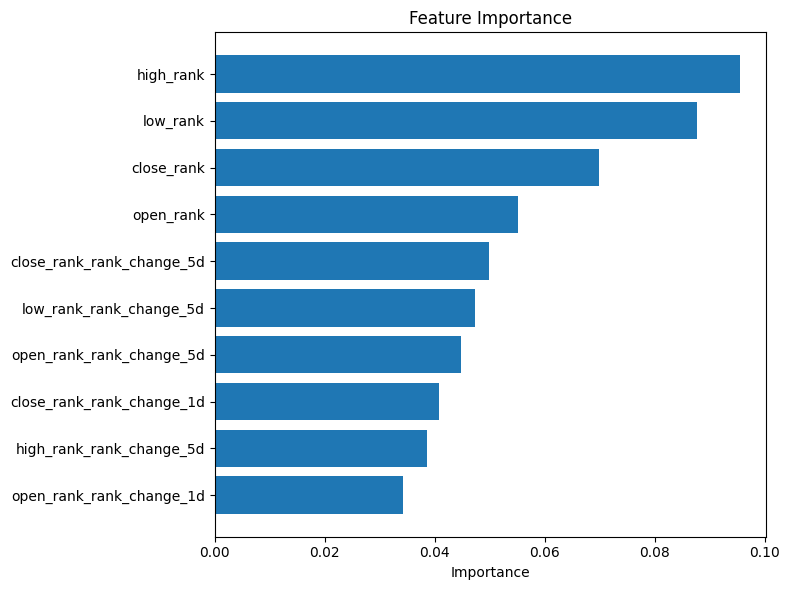

In [89]:
plot_feature_importance(quintile_rank_model, modeling_features, top_n=10)

### Evaluate performance when rebalancing stocks monthly


=== Strategy vs SPY Alpha (Intercept) and Beta (Slope) ===
Alpha: -0.000988  |  p-value: 0.666084
Beta:  0.824928  |  p-value: 0.000000

=== Strategy vs SPY Comparison ===
Metric                     Strategy            SPY
--------------------------------------------------
Annual Return                 9.07%         12.69%
Volatility                   13.56%         15.15%
Sharpe                         0.64           0.79
Max Drawdown                -20.81%        -21.81%
CAGR                          8.10%         12.45%


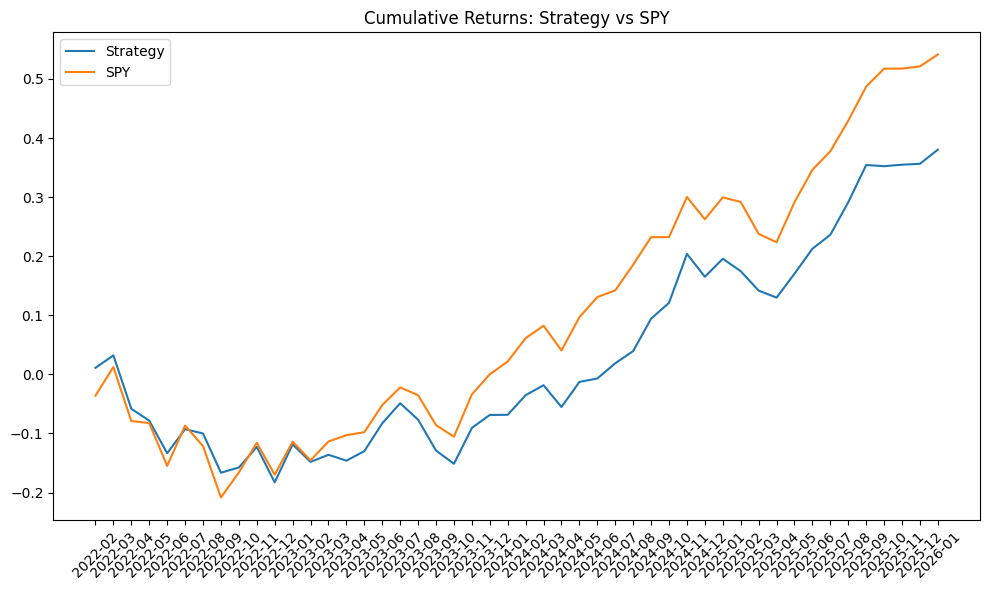

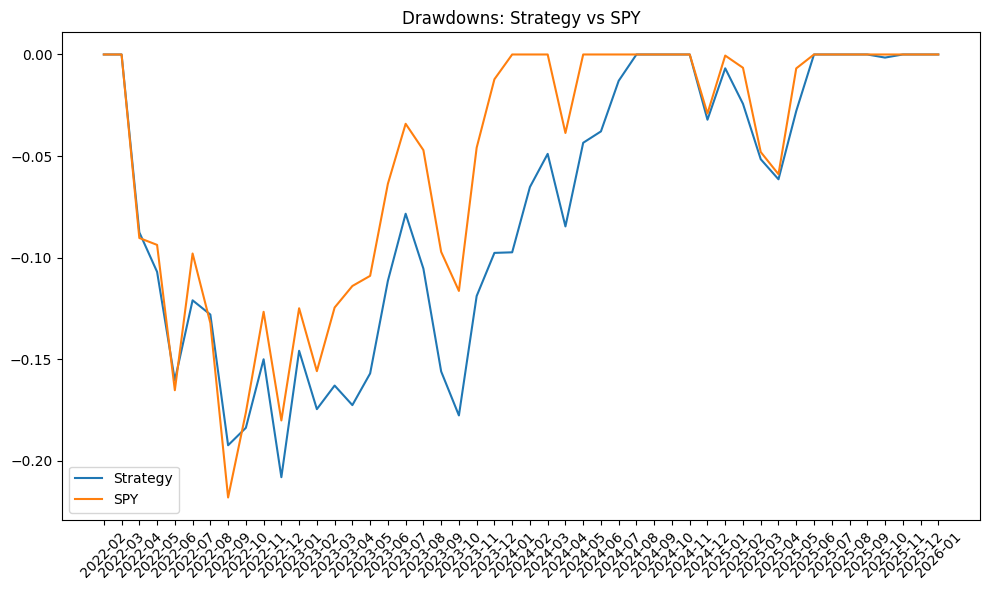

,month,portfolio_value,turnover,monthly_return,cumulative_return,year_month,monthly_return_spy,portfolio_value_spy,cumulative_return_spy
0,2022-02,10110.571902,10000.000000,0.000000,0.011057,2022-02,-0.036030,9639.695179,-0.036030
1,2022-03,10321.779160,10110.571902,0.020890,0.032178,2022-03,0.050374,10125.289456,0.012529
2,2022-04,9417.870751,10321.779160,-0.087573,-0.058213,2022-04,-0.090347,9210.498835,-0.078950
3,2022-05,9217.199117,9417.870751,-0.021308,-0.078280,2022-05,-0.003740,9176.054612,-0.082395
4,2022-06,8666.082087,9217.199117,-0.059792,-0.133392,2022-06,-0.078957,8451.540891,-0.154846
5,2022-07,9072.470022,8666.082087,0.046894,-0.092753,2022-07,0.080658,9133.224054,-0.086678
6,2022-08,9000.096934,9072.470022,-0.007977,-0.099990,2022-08,-0.037953,8786.589846,-0.121341
7,2022-09,8335.857845,9000.096934,-0.073804,-0.166414,2022-09,-0.098986,7916.840701,-0.208316
8,2022-10,8424.478658,8335.857845,0.010631,-0.157552,2022-10,0.053463,8340.097383,-0.165990
9,2022-11,8772.860384,8424.478658,0.041354,-0.122714,2022-11,0.060231,8842.429359,-0.115757


In [ ]:
backtest_monthly_dollar(
        test, 
        pred_col="pred_quartile_rank", 
        long_class=3, 
        top_pct=None, 
        price_col="close"
)

## 2) Lambda Rank Model

In [91]:
# Sort train and test by date to create groups
train = train.sort_values("date").reset_index(drop=True)
test = test.sort_values("date").reset_index(drop=True)

In [ ]:
# --- Create excess SPY returns by adding forward returns for SPY
# Compute SPY forward returns
spy_forward = (
    train[train["ticker"] == "SPY"]
    .sort_values("date")
    .assign(
        return_t10_spy=lambda x: x["close"].shift(-10) / x["close"] - 1
    )
    [["date", "return_t10_spy"]]
)

# Merge onto full dataset by date
train = train.merge(spy_forward, on="date", how="left")

# Create excess return label
train["excess_return_t+10"] = train["return_t+10"] - train["return_t10_spy"]

# Create dmatrix and drop NaN values
train = train.loc[train["excess_return_t+10"].notna(), :]

X_train = train[modeling_features]

dtrain = xgb.DMatrix(X_train, label=train["excess_return_t+10"], enable_categorical=True)

# Number of stocks per date
group_train = train.groupby("date").size().values
dtrain.set_group(group_train)

In [120]:
train.shape

(3082438, 188)

In [121]:
# XGBoost Rank model
params = {
    "objective": "rank:pairwise",
    "eval_metric": "ndcg",
    "learning_rate": 0.05,
    "max_depth": 6,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "colsample_bylevel": 0.8,
    "tree_method": "hist",
    "seed": 42
}

rank_model = xgb.train(
    params,
    dtrain,
    num_boost_round=50
)

# Make predictions on test set
X_test = test[modeling_features]
dtest = xgb.DMatrix(X_test, enable_categorical=True)
test['pred_rank'] = rank_model.predict(dtest)

In [ ]:
backtest_monthly_dollar(
        test, 
        pred_col="pred_rank", 
        long_class=None,         
        top_pct=0.20, 
        price_col="close",
        short_class=None,
        short_pct=0.20,
        initial_capital=10000,
        transaction_cost_bps=20,
        monthly_contribution=0,
        short_term_tax_rate=0.35,
        borrow_cost_annual=0.03
)

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

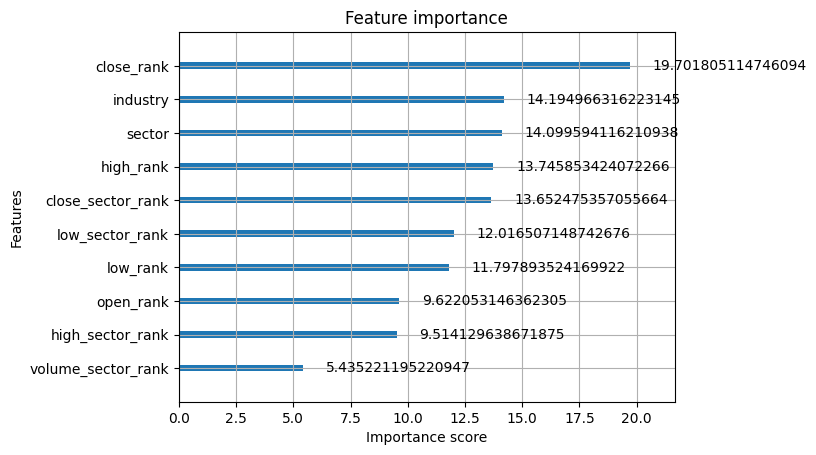

In [127]:
xgb.plot_importance(rank_model, importance_type='gain', max_num_features=10)


In [80]:
import statsmodels.api as sm

y = results["monthly_return"]
X = results["monthly_return_spy"]
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()
print(model.summary())

ModuleNotFoundError: No module named 'statsmodels'

In [81]:
%pip install statsmodels

   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ------------- -------------------------- 3.1/9.6 MB 17.4 MB/s eta 0:00:01
   ---------------------------- ----------- 6.8/9.6 MB 17.5 MB/s eta 0:00:01
   ---------------------------------------- 9.6/9.6 MB 16.0 MB/s  0:00:00

   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -----------------